# Running a Real Hypothesis Test in Python

Now we move from concept to practice.

You are still the data scientist at the food delivery company.

We ran an A/B test:

- **Group A** → Old recommendation system
- **Group B** → New recommendation system

Each user places one order. We record the order value.

Our question:

> Does the new system increase average order value?

We will answer this using a **two-sample t-test**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Step 1: Create Sample Data
'''
We simulate realistic order values.

Assumptions:

- Old system average ≈ $24
- New system average ≈ $25.5
- Natural variation exists

'''
np.random.seed(42)

# sample sizes
n_old = 200
n_new = 200

# simulate order values
old_orders = np.random.normal(loc=24.0, scale=5, size=n_old)
new_orders = np.random.normal(loc=25.5, scale=5, size=n_new)

print("Old mean:", round(old_orders.mean(), 2))
print("New mean:", round(new_orders.mean(), 2))

Old mean: 23.8
New mean: 25.93


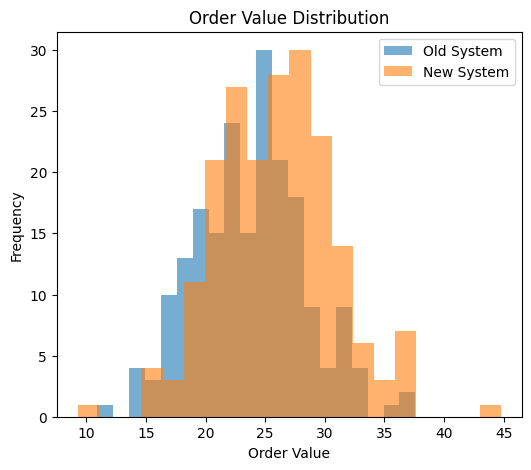

In [ ]:
## Step 2: Visualize the Distributions
'''
Before statistics, always look at the data.

Do the groups look different?
'''

plt.figure(figsize=(6,5))
plt.hist(old_orders, alpha=0.6, bins=20, label="Old System")
plt.hist(new_orders, alpha=0.6, bins=20, label="New System")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.legend()
plt.title("Order Value Distribution")
plt.show()

In [ ]:
## Step 3: Perform the Two-Sample t-Test

'''
This test compares the means of two independent groups.
It evaluates whether the difference is statistically significant.
'''
t_stat, p_value = stats.ttest_ind(new_orders, old_orders)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 6))


## Step 4: Decision
'''
Decision rule:

If p-value < 0.05 → reject null hypothesis

'''

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
    print("Evidence suggests the new system changes order value")
else:
    print("Fail to reject the null hypothesis")
    print("No strong evidence of change")

t-statistic: 4.4469
p-value: 1.1e-05
Reject the null hypothesis
Evidence suggests the new system changes order value
